# Sleep Health and Lifestyle Analysis
## Identifying Key Factors Affecting Sleep Quality and Duration

This notebook explores the Sleep Health and Lifestyle dataset to identify which 
lifestyle and health factors most strongly influence sleep quality, sleep duration, 
and the likelihood of sleep disorders.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [36]:
df = pd.read_csv(r"C:\Users\Ansh Verma\Downloads\Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [37]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


**Data Cleaning:**

In [38]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")
df.drop_duplicates(inplace=True)
print(df.shape)

(374, 13)


**Exploratory Data Analysis**

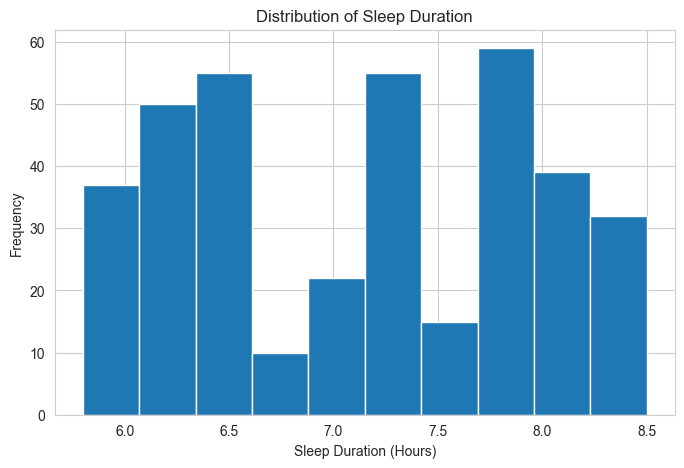

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['Sleep Duration'], bins=10)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Frequency')

plt.show()

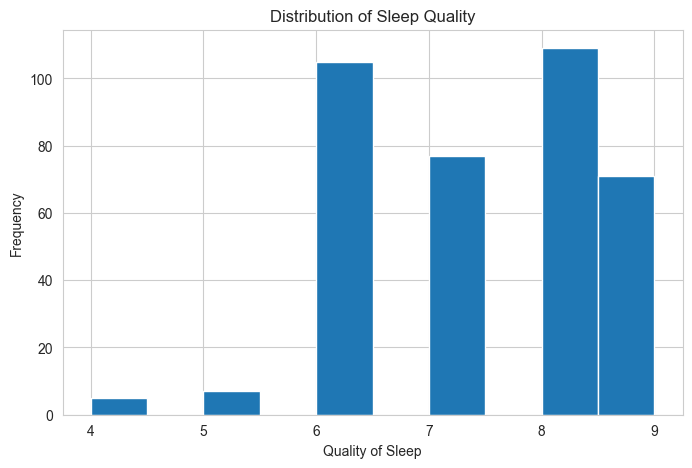

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df['Quality of Sleep'], bins=10)
plt.title('Distribution of Sleep Quality')
plt.xlabel('Quality of Sleep')
plt.ylabel('Frequency')

plt.show()

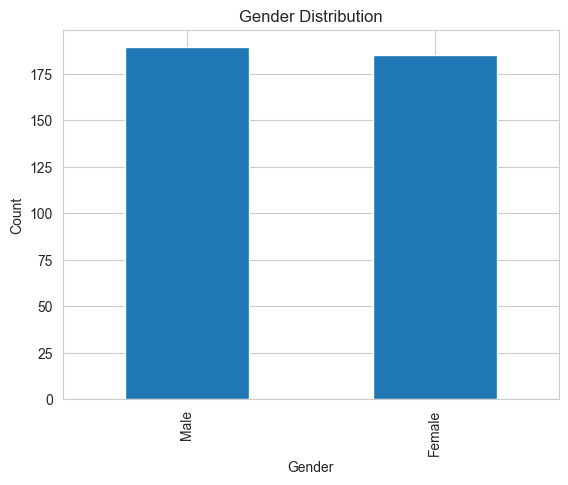

In [41]:
df['Gender'].value_counts().plot(
    kind='bar'
)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

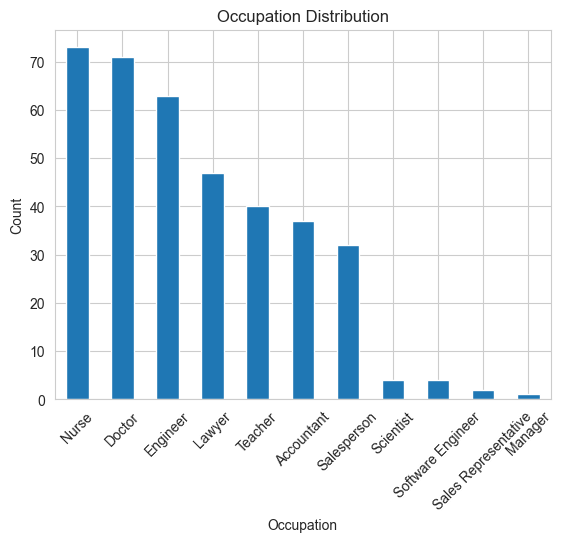

In [42]:
df['Occupation'].value_counts().plot(
    kind='bar'
)
plt.title('Occupation Distribution')
plt.xlabel('Occupation')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

**KEY FACTOR ANALYSIS:**

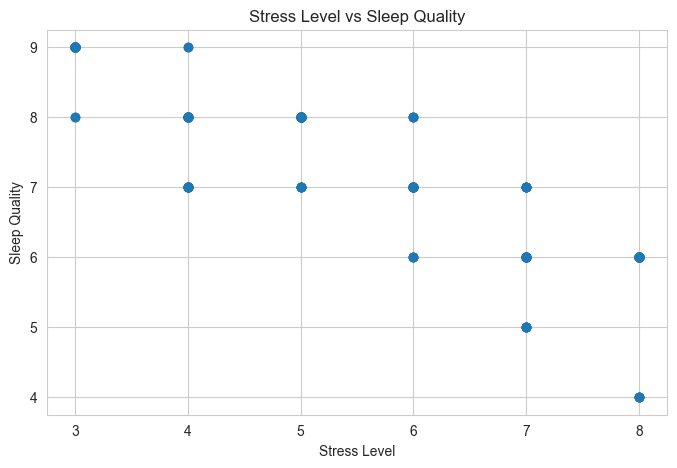

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(df['Stress Level'],df['Quality of Sleep'])
plt.title('Stress Level vs Sleep Quality')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Quality')

plt.show()

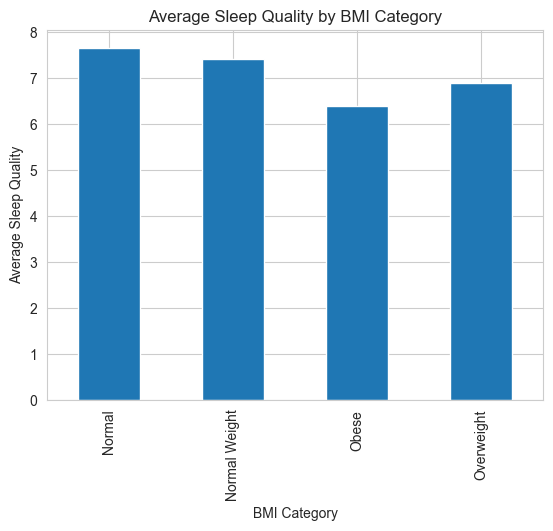

In [45]:
bmi_quality = df.groupby(
    'BMI Category'
)['Quality of Sleep'].mean()
bmi_quality.plot(kind='bar')
plt.title('Average Sleep Quality by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Sleep Quality')
plt.show()

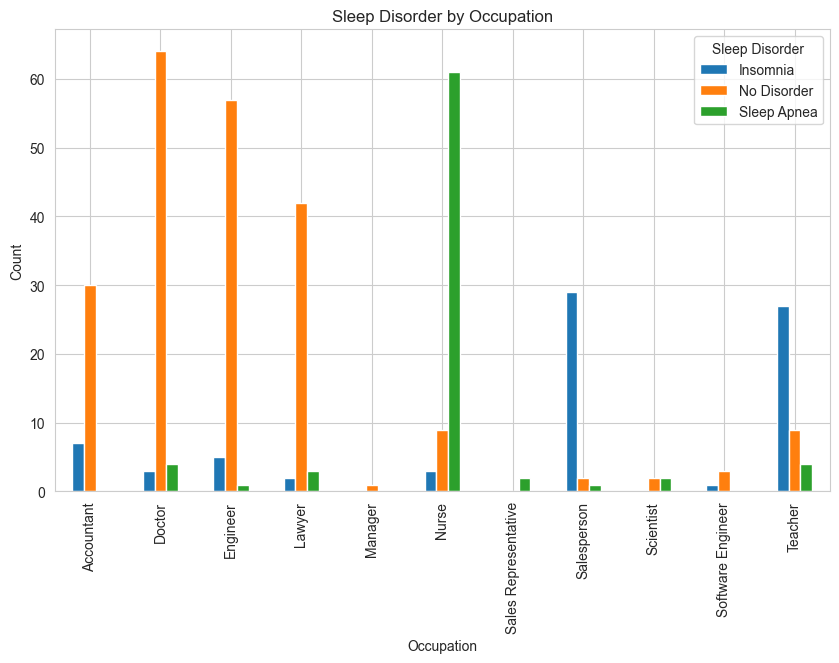

In [46]:
import pandas as pd
cross_tab = pd.crosstab(
    df['Occupation'],
    df['Sleep Disorder']
)
cross_tab.plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Sleep Disorder by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.show()

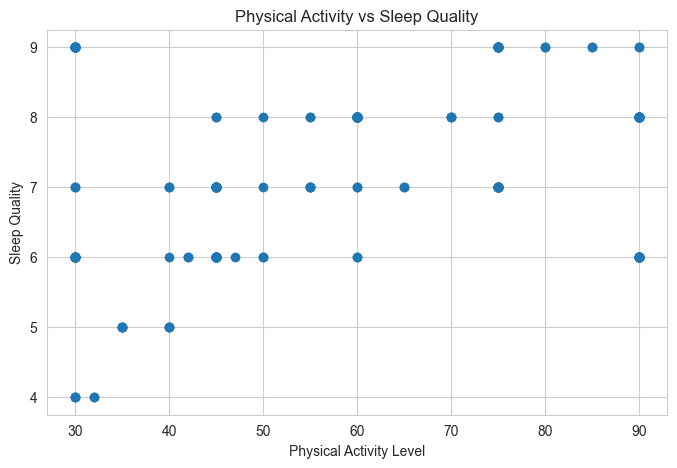

In [47]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['Physical Activity Level'],
    df['Quality of Sleep']
)
plt.title('Physical Activity vs Sleep Quality')
plt.xlabel('Physical Activity Level')
plt.ylabel('Sleep Quality')

plt.show()

**Corelation Heatmap:**

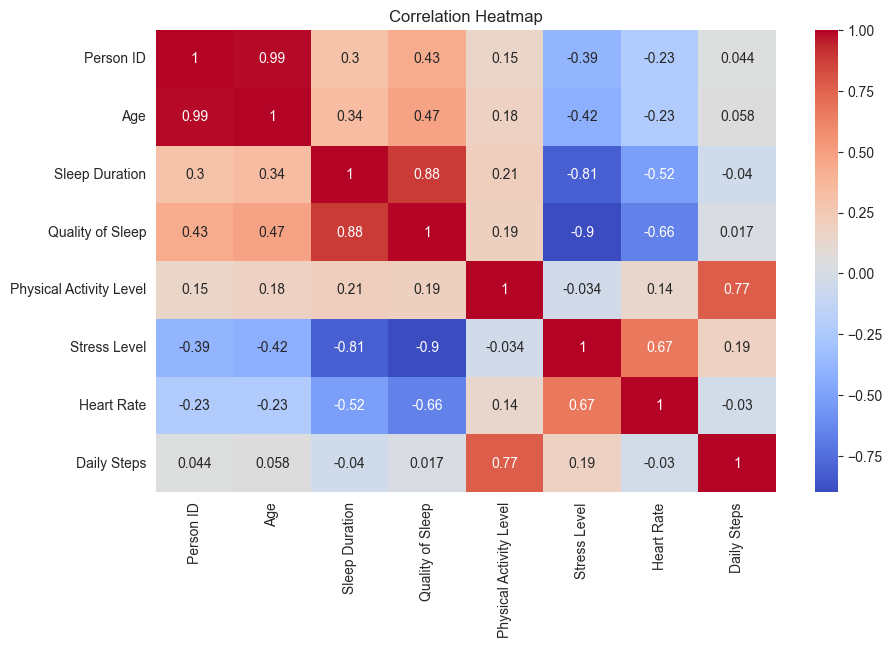

In [48]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

**ANOVA: Sleep Quality across BMI categories:**

F-statistic: 14.93, p-value: 0.0000


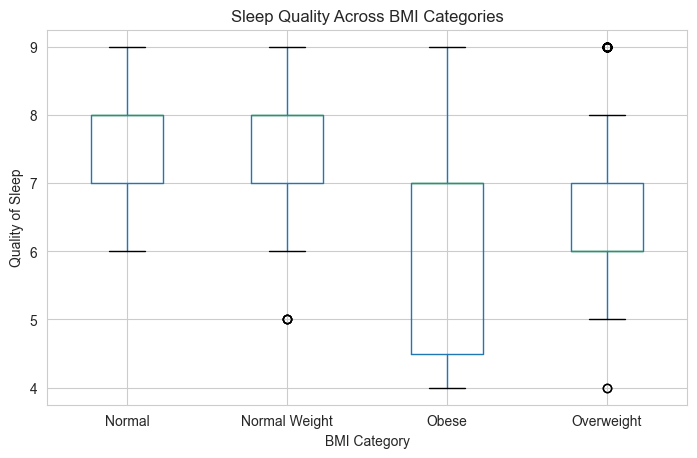

In [53]:
from scipy import stats
groups = [df[df['BMI Category'] == cat]['Quality of Sleep'] for cat in df['BMI Category'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_val:.4f}")

df.boxplot(
    column='Quality of Sleep',
    by='BMI Category',
    figsize=(8,5)
)

plt.title('Sleep Quality Across BMI Categories')
plt.suptitle('')
plt.xlabel('BMI Category')
plt.ylabel('Quality of Sleep')

plt.show()

## Key Findings
- (Fill in after running the above — e.g., "Stress Level shows the strongest negative 
  correlation with Quality of Sleep (r = -0.xx)")
- (e.g., "Sales Representatives and Nurses show the highest rate of Sleep Apnea")
- (e.g., "Higher Physical Activity Level is associated with better sleep quality, 
  except in the Obese category")

## Recommendations
- Practical lifestyle suggestions based on findings

## Limitations
- Self-reported data, sample size of 373, no causal inference possible